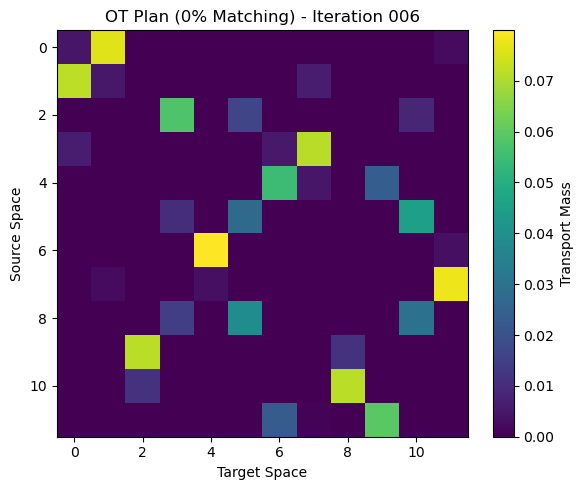

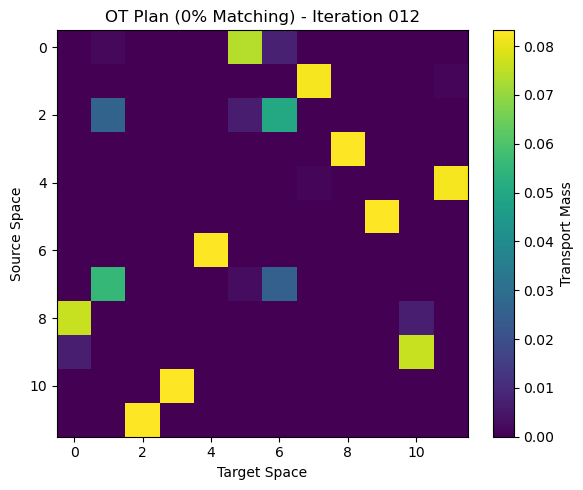

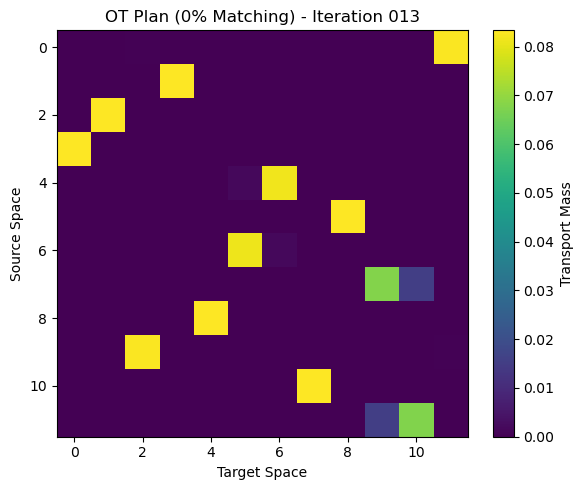

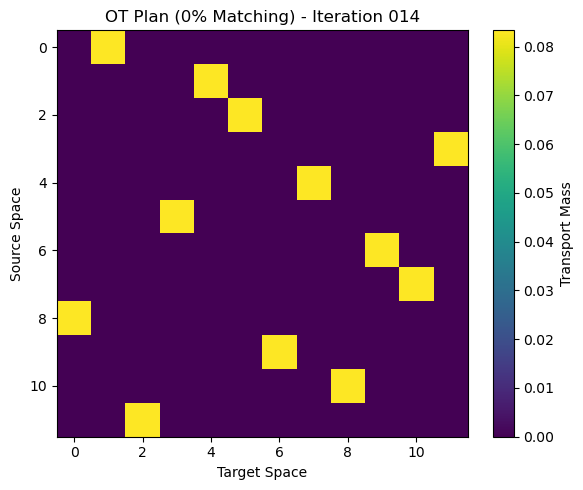

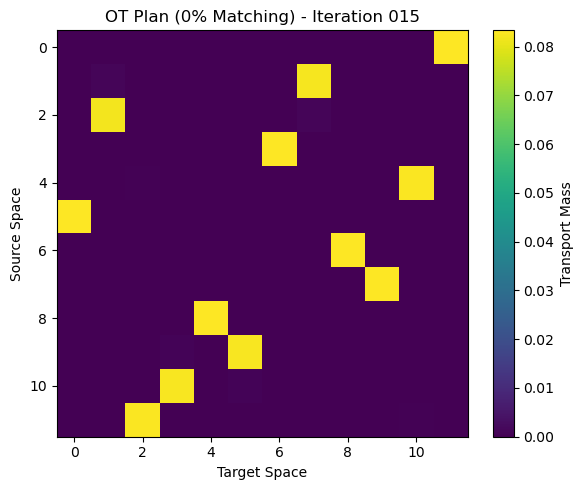

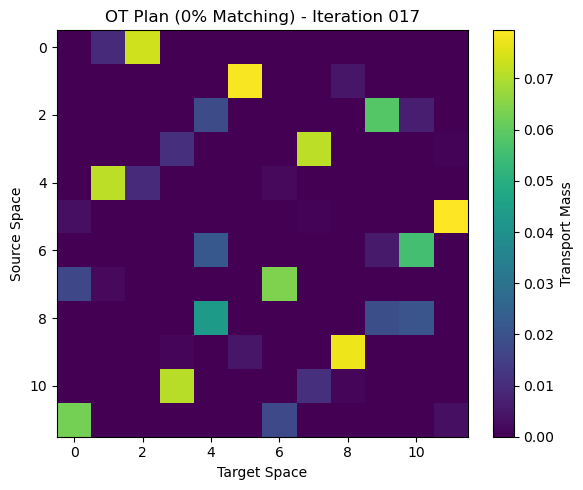

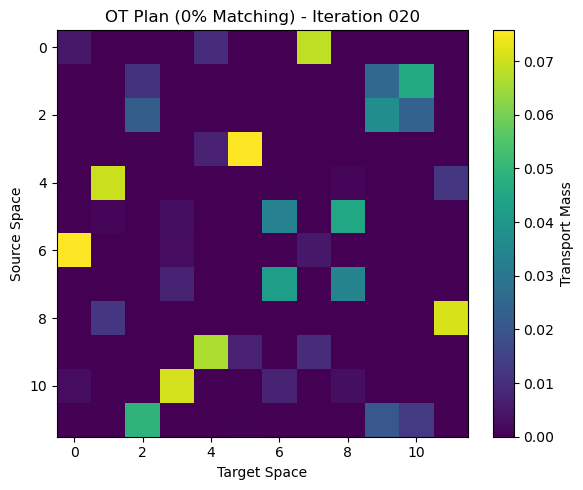

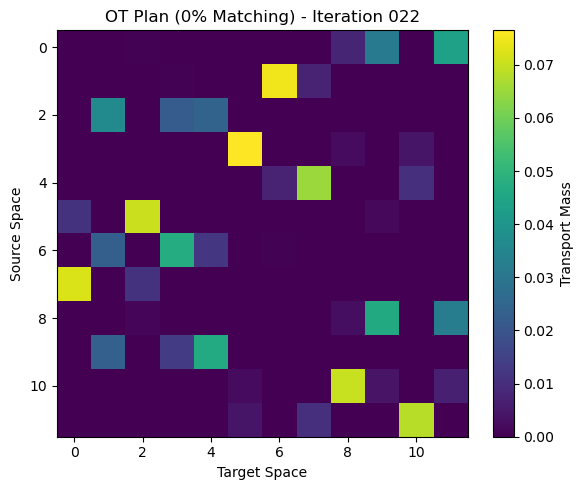

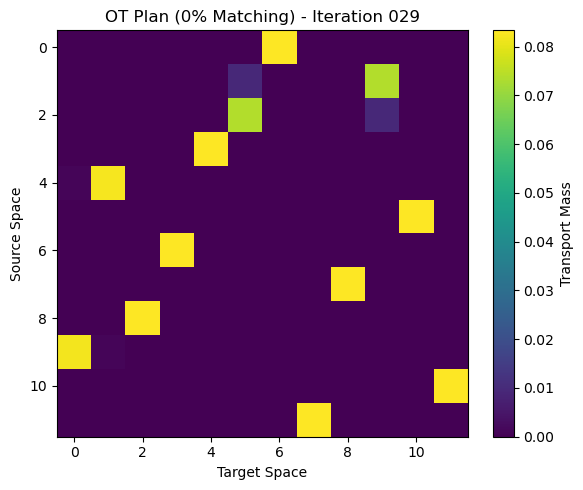

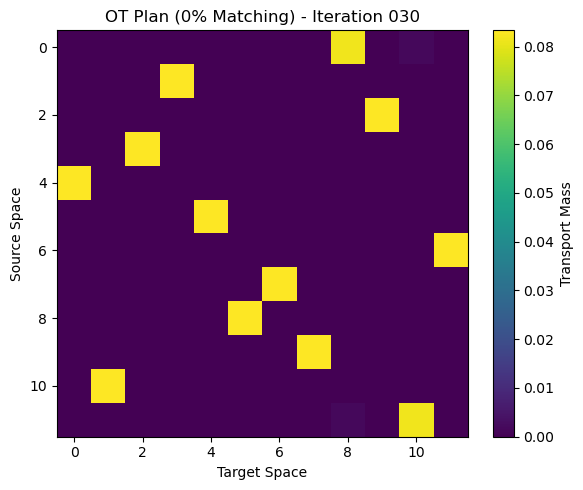

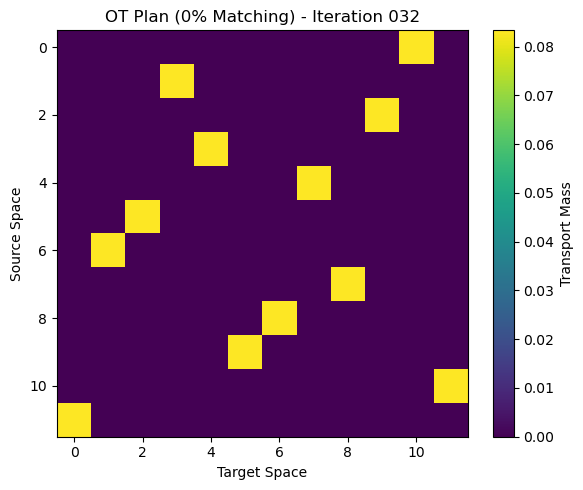

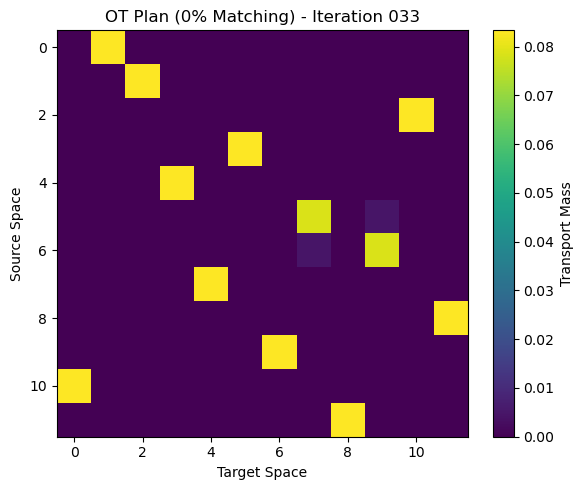

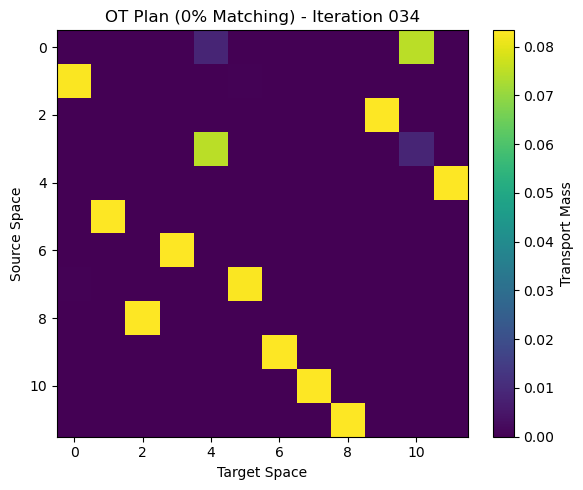

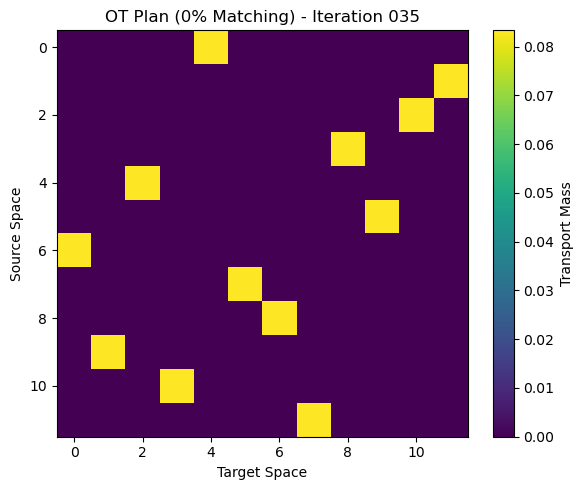

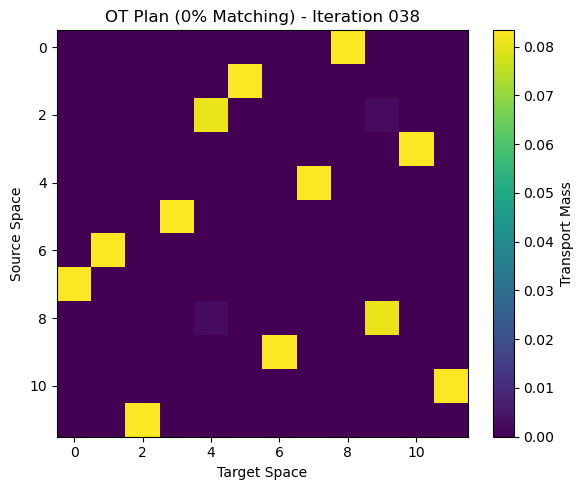

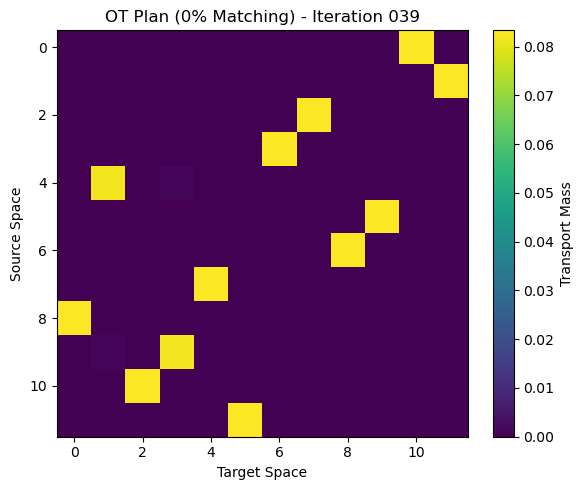

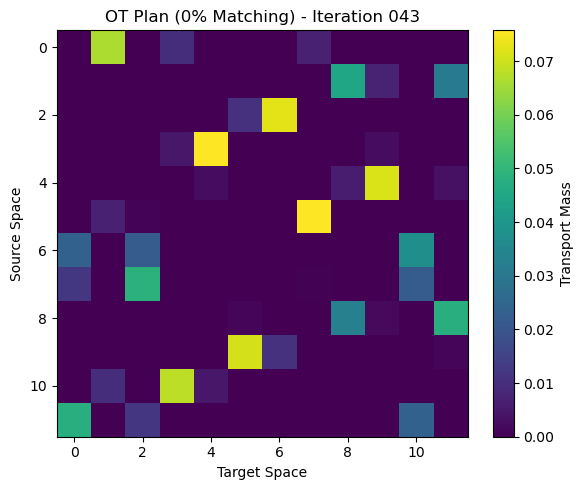

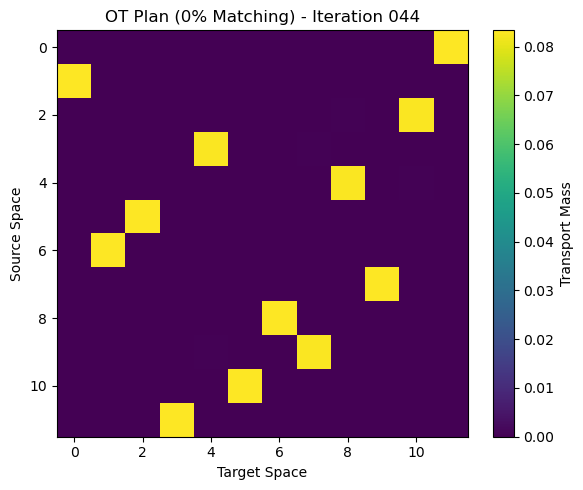

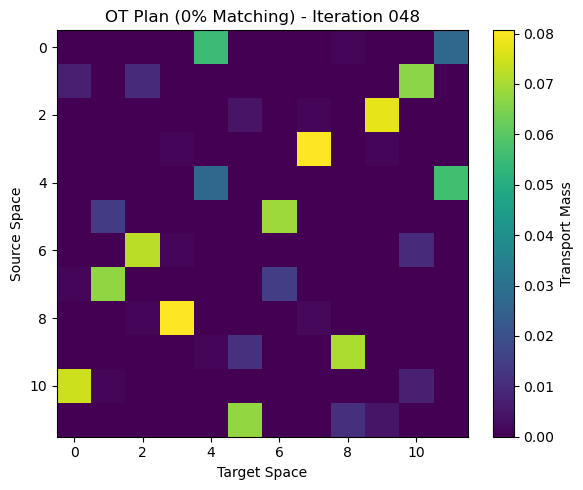

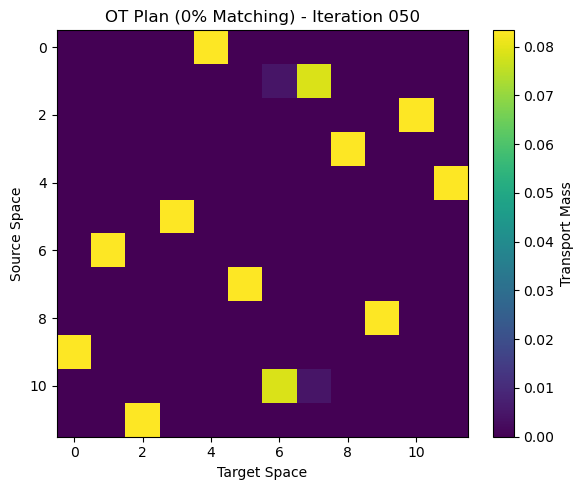

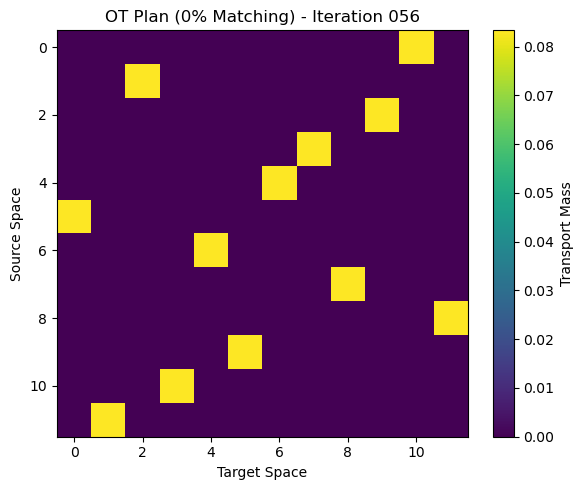

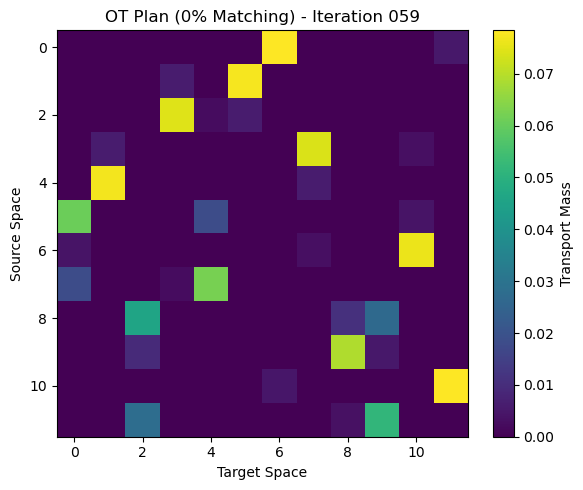

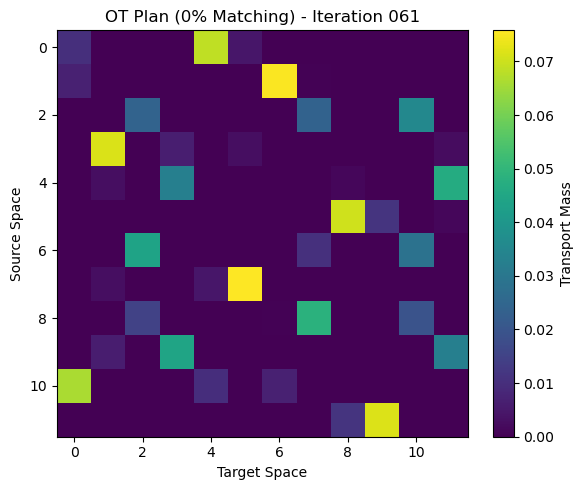

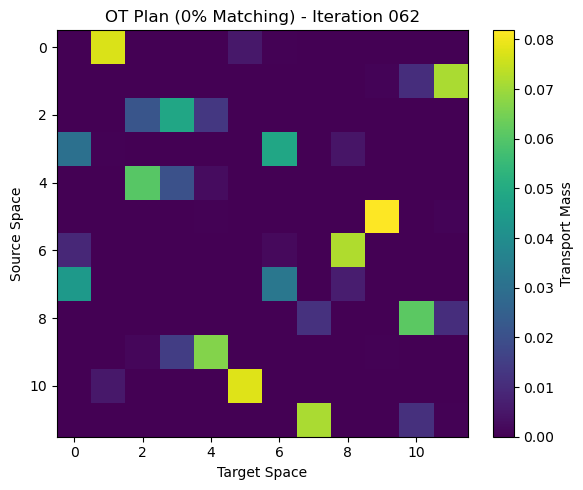

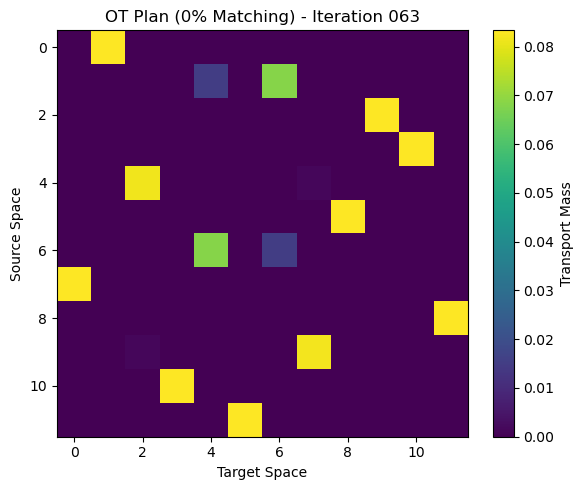

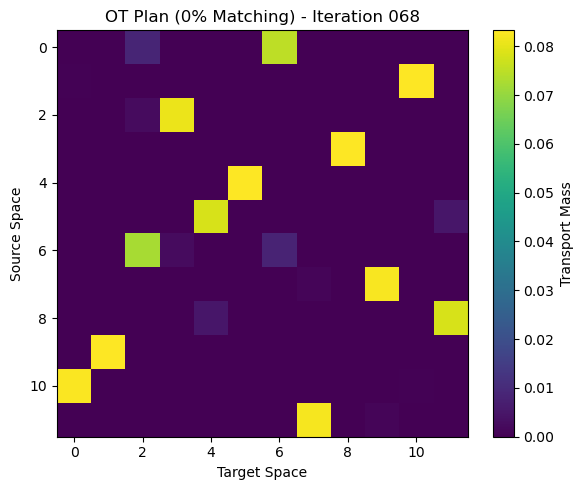

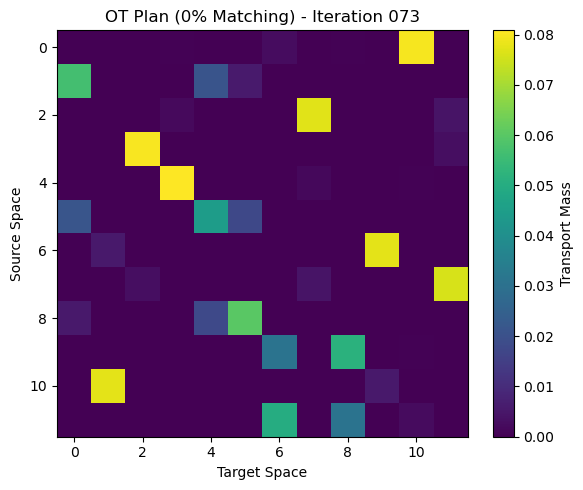

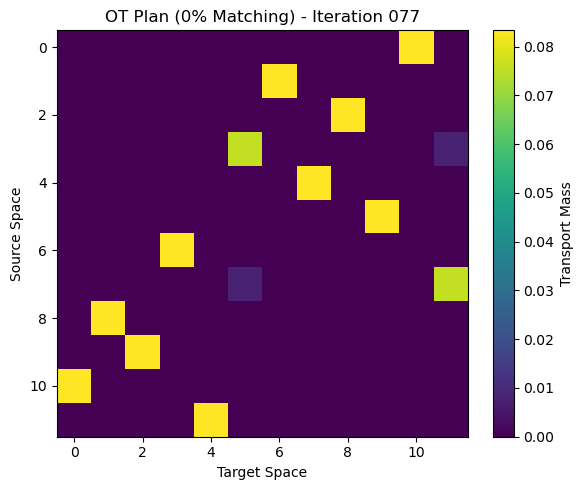

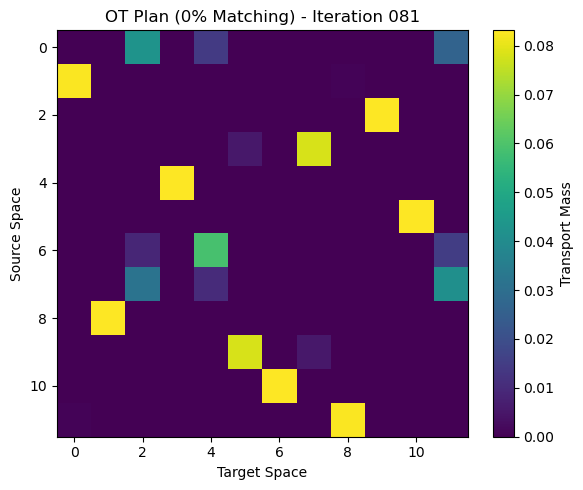

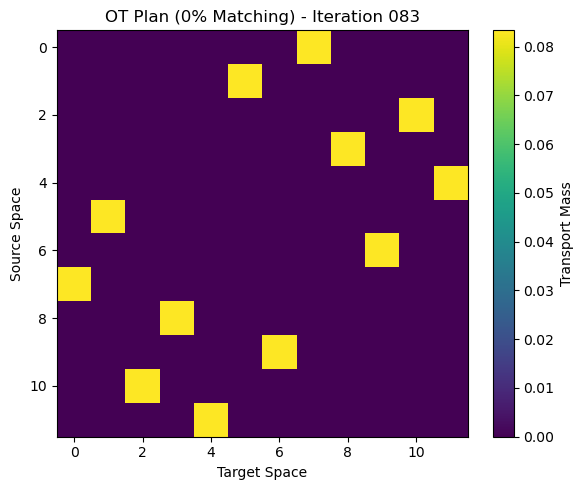

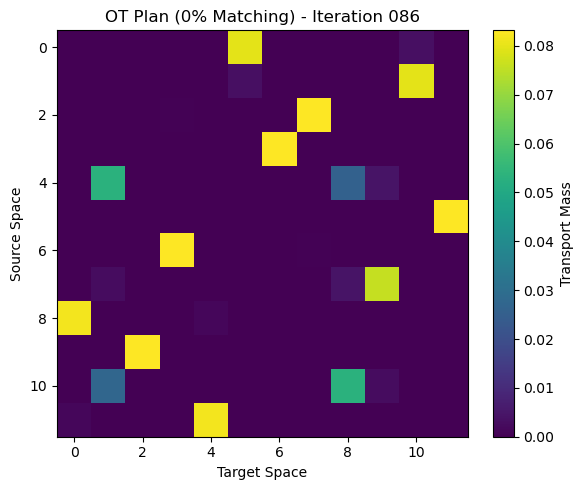

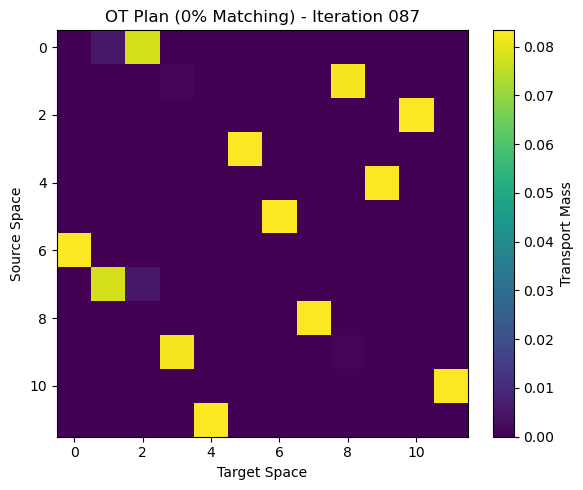

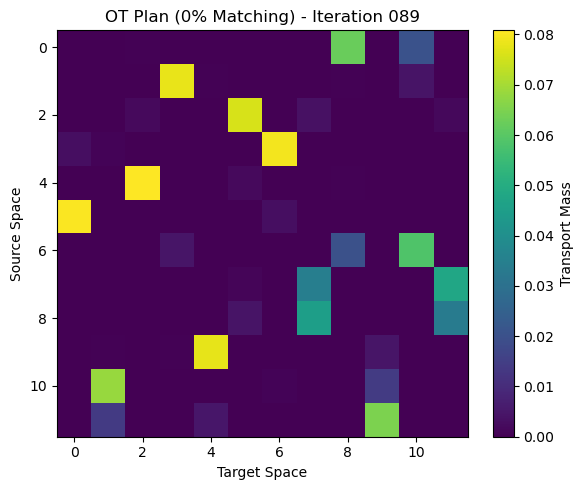

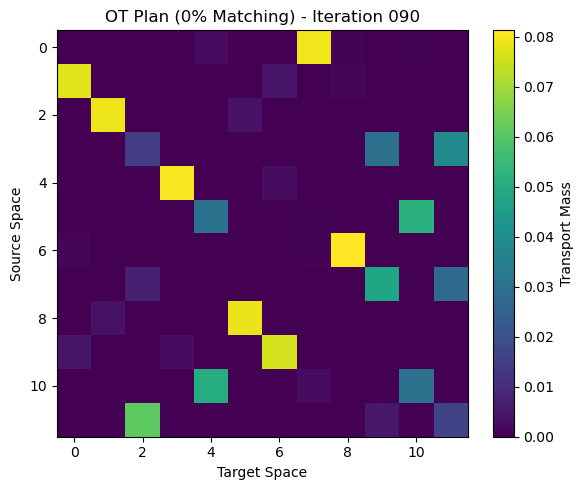

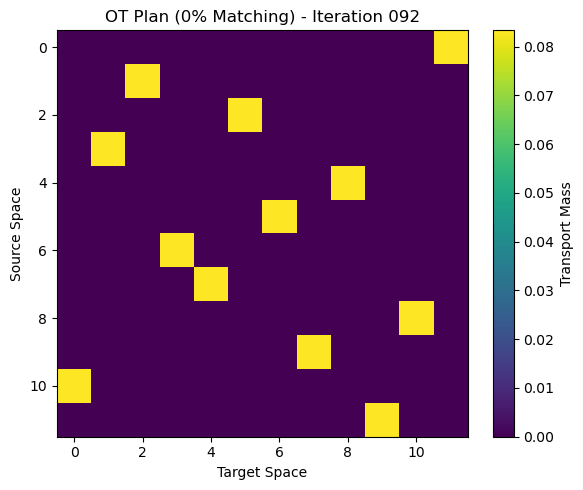

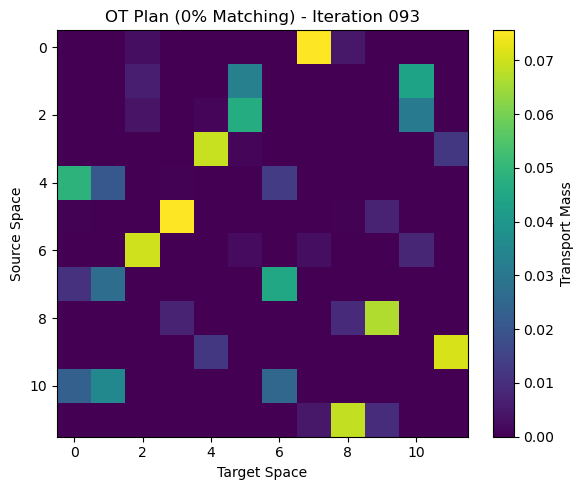

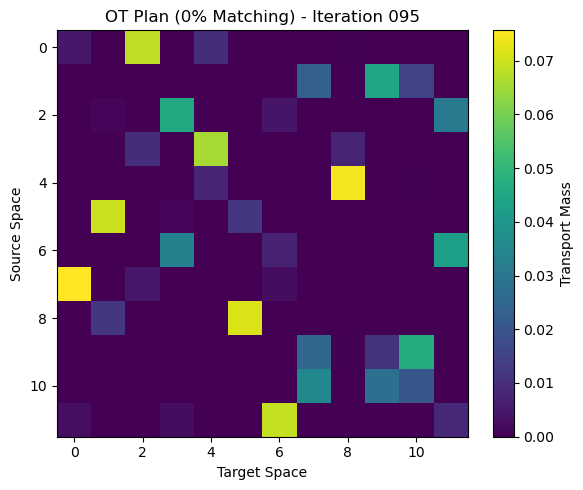

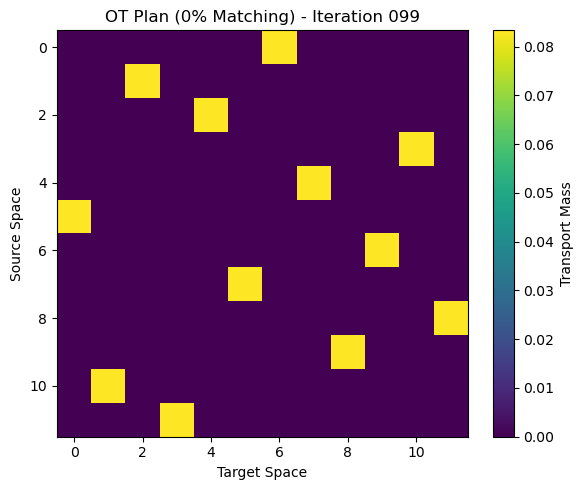

In [11]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import random

# Directory containing saved results
results_dir = "gwot_results_similarity_distance_averaged_shuffled"

# Store (iteration index, OT plan) for iterations with 0% match rate
zero_match_ot_plans = []

# Loop through all iteration files
for filename in sorted(os.listdir(results_dir)):
    if filename.startswith("iteration_") and filename.endswith(".pkl"):
        filepath = os.path.join(results_dir, filename)

        with open(filepath, "rb") as f:
            result = pickle.load(f)

        best_matching_rate = result.get("best_matching_rate", None)
        if best_matching_rate == 0:
            ot_plan = result.get("OT_plan", None)
            iteration_idx = result.get("iteration", "???")
            if ot_plan is not None:
                zero_match_ot_plans.append((iteration_idx, ot_plan))

# Plot OT plans for 0% matching rate iterations
for idx, ot_plan in zero_match_ot_plans:
    plt.figure(figsize=(6, 5))
    plt.imshow(ot_plan, cmap="viridis", aspect='auto')
    plt.colorbar(label='Transport Mass')
    plt.title(f"OT Plan (0% Matching) - Iteration {idx:03d}")
    plt.xlabel("Target Space")
    plt.ylabel("Source Space")
    plt.tight_layout()
    # Optional: save to file
    # plt.savefig(f"ot_plan_0match_iter_{idx:03d}.png")
    plt.show()


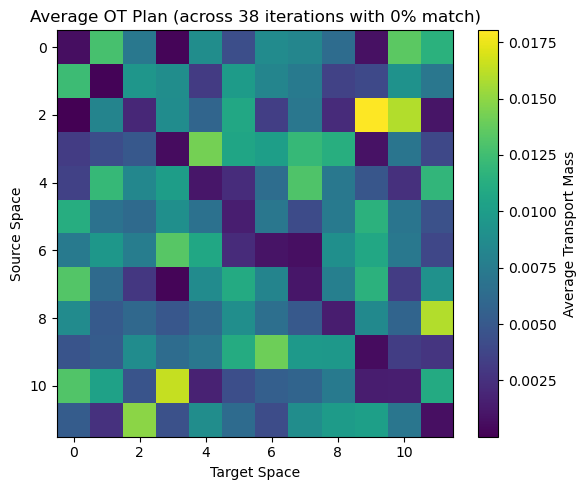

In [12]:
# Compute and plot the average OT plan
if zero_match_ot_plans:
    # Stack all OT plans into a 3D array
    all_plans = np.stack([plan for _, plan in zero_match_ot_plans], axis=0)
    avg_plan = np.mean(all_plans, axis=0)

    # Plot average OT plan
    plt.figure(figsize=(6, 5))
    plt.imshow(avg_plan, cmap="viridis", aspect='auto')
    plt.colorbar(label='Average Transport Mass')
    plt.title(f"Average OT Plan (across {len(zero_match_ot_plans)} iterations with 0% match)")
    plt.xlabel("Target Space")
    plt.ylabel("Source Space")
    plt.tight_layout()
    plt.show()
else:
    print("No iterations with 0% matching rate found.")


/var/folders/zk/lv_zrs9910s49_109vbgf6c40000gn/T/ipykernel_31744/3297978315.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


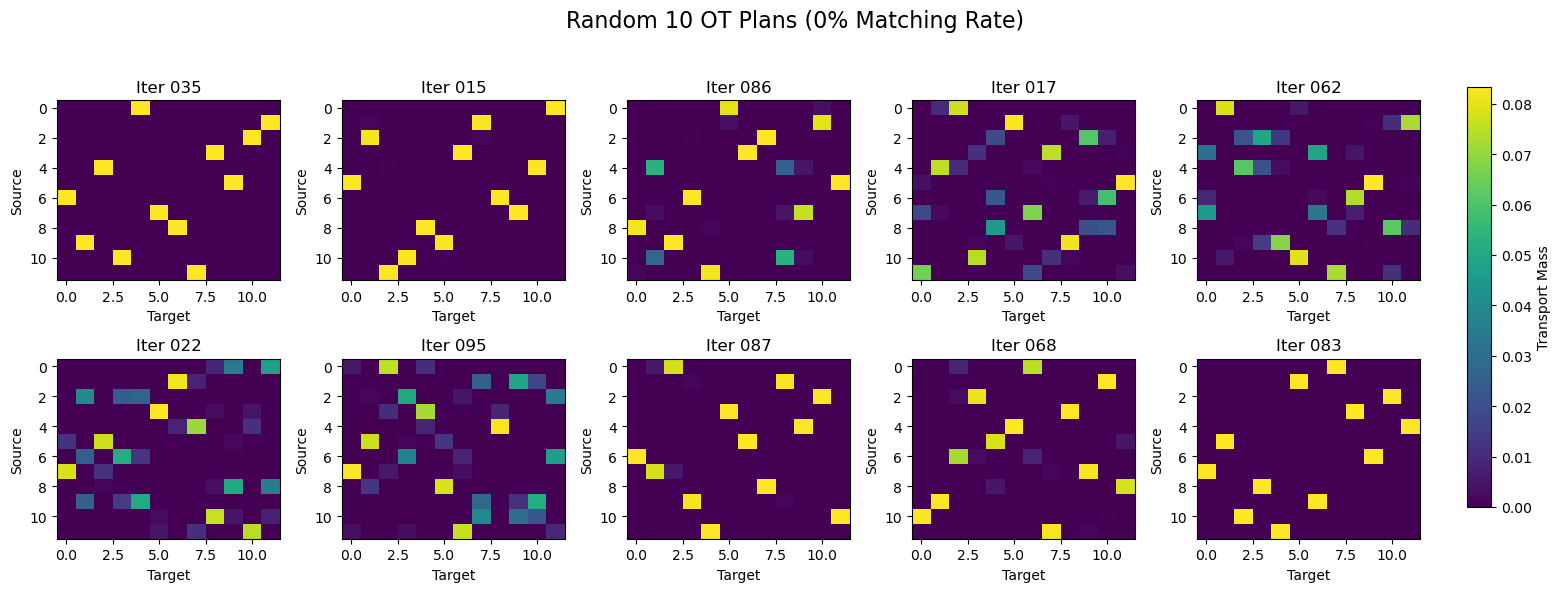

In [13]:
# --- Randomly sample 10 plans to plot ---
n_to_plot = 10
nrows=2
ncols=5
if len(zero_match_ot_plans) < n_to_plot:
    raise ValueError(f"Not enough OT plans with 0% match rate. Found only {len(zero_match_ot_plans)}.")

sampled_plans = random.sample(zero_match_ot_plans, n_to_plot)

# --- Plot in a grid ---
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6))
axes = axes.flatten()

for ax, (idx, ot_plan) in zip(axes, sampled_plans):
    im = ax.imshow(ot_plan, cmap="viridis", aspect='auto')
    ax.set_title(f"Iter {idx:03d}")
    ax.set_xlabel("Target")
    ax.set_ylabel("Source")

# Colorbar (shared)
fig.subplots_adjust(right=0.9, wspace=0.4, hspace=0.6)
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Transport Mass")

fig.suptitle("Random 10 OT Plans (0% Matching Rate)", fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()
